# ACCESS-OM3 MC 100km JRA RYF Scaling

End-to-end pipeline generating scaling plots for [ACCESS-OM3 MC 100km JRA RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_100km_jra_ryf).

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling",):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.4
access.profiling: 0.2.dev29+g2022a4bd3


## Setup
The following variables control where the configurations and model run outputs are saved.

In [3]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

test_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive"

GLOBAL_GRID = Domain(shape=(360, 324))
OM3_MC_100KM = OM3Configuration(
    name="MC-100km",
    ocean=GLOBAL_GRID,
    sea_ice=GLOBAL_GRID,
    atmosphere=GLOBAL_GRID,
    runoff=GLOBAL_GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(test_path), archive_dir=Path(archive_path), configuration=OM3_MC_100KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="dev-MC_100km_jra_ryf")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]`. We will search for different layouts that closely match a scaled 5-node 100km RYF config.

In [4]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

# Define how the cores should be allocated to the components
allocation_strategy = RootAllocation(
    subcomponents={
        "ocn": FreeAllocation(min_core_fraction=0.85,),
        "shared": FreeAllocation(min_core_fraction=0.05,
            subcomponents={
                "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.5),),),
                "cpl": WholeRangeAllocation(),
                "rof": WholeRangeAllocation(),
                "atm": WholeRangeAllocation(),
            },
        ),
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.01),),
)

In [5]:
###### Generate the configuration and write to file
num_nodes_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
control_options = {
            "config.yaml": {
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "mem": "REMOVE",
            }
}

def walltime(num_nodes):
    return 4 * 4.0/num_nodes # use a 4 hrs time for 4-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=48, walltime=walltime, allocations=allocation_strategy)

-- Test directory /scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf already exists!
-- Test dir: /scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/config already exists, hence not cloning https://github.com/ACCESS-NRI/access-om3-configs.git
Checked out branch: ctrl
laboratory path:  /scratch/tm70/mo1833/access-om3
binary path:  /scratch/tm70/mo1833/access-om3/bin
input path:  /scratch/tm70/mo1833/access-om3/input
work path:  /scratch/tm70/mo1833/access-om3/work
archive path:  /scratch/tm70/mo1833/access-om3/archive
Metadata and UUID generation is disabled. Experiment name used for archival: config
No prior restart path provided. Skip adding parent branch time to metadata.
Removed archive symlink to /scratch/tm70/mo1833/access-om3/archive/om3-layout_MC-100km_atm_35_cpl_35_ice_7x5_ocn_346_rof_35
Removed work symlink to /scratch/tm70/mo1833/access-om3/work/om3-layout_MC-100km_atm_35_cpl_35_ice_7x5_ocn_346_rof_35
-- Branch om3-layout_MC-100km_atm_6_cpl_6_ice_3x2_ocn_42_

## Run experiments

Next we run the experiments

In [6]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [7]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count
best_experiments = om3_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

Experiment 'om3-layout_MC-100km_atm_6_cpl_6_ice_3x2_ocn_42_rof_6' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_25_cpl_25_ice_5x5_ocn_167_rof_25' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_179_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_4x3_ocn_179_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_167_rof_24' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_227_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_4x3_ocn_227_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_16

['om3-layout_MC-100km_atm_4_cpl_4_ice_2x2_ocn_44_rof_4',
 'om3-layout_MC-100km_atm_15_cpl_15_ice_5x3_ocn_81_rof_15',
 'om3-layout_MC-100km_atm_15_cpl_15_ice_5x3_ocn_128_rof_15',
 'om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_168_rof_24',
 'om3-layout_MC-100km_atm_35_cpl_35_ice_7x5_ocn_204_rof_35',
 'om3-layout_MC-100km_atm_42_cpl_42_ice_7x6_ocn_245_rof_42',
 'om3-layout_MC-100km_atm_54_cpl_54_ice_9x6_ocn_328_rof_54']

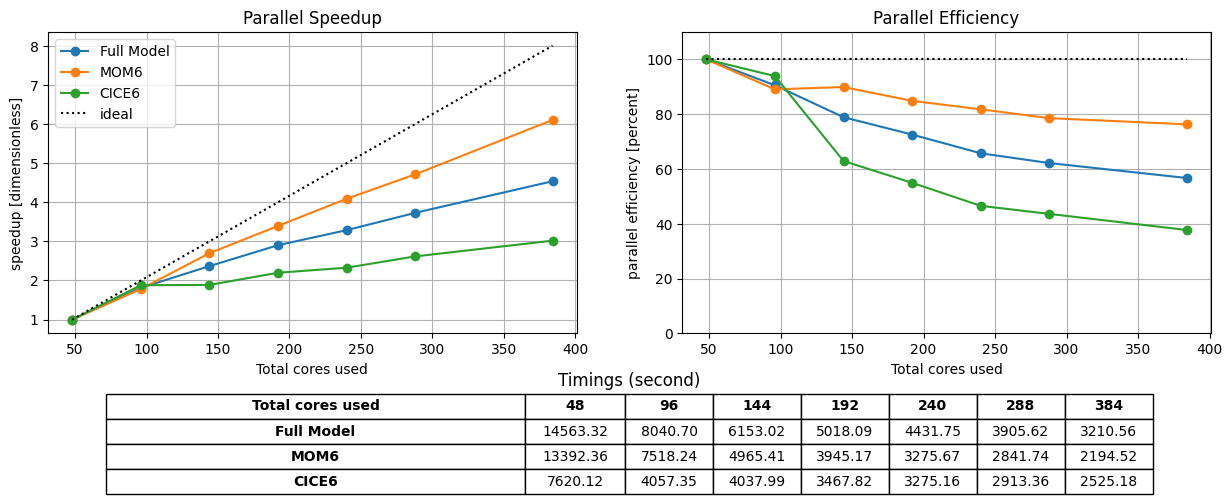

In [11]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu", "MOM6", "CICE6"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean"],
        ["Total"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="Total cores used",
)

## Summary

We have presented the strong scaling results for the [100km RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_100km_jra_ryf) of ACCESS-OM3. The underlying components are MOM6 for ocean, CICE6 for the ice model, using the NUOPC coupler from ESMF. The atmosphere and runoff are applied as forcings. Atmosphere, coupler, runoff, and CICE all share the same cores and run concurrently with MOM6. The released configuration for ACCESS-OM3 100km RYF configuration uses 5-nodes on the `normal` queue with `cascadelake` cpus, where each node contains 48 cores. The table shows the raw data from the runs corresponding to each of the components, and the overall model runtime. The columns represent 1, 2, 3, 4, 5, 6, and 8 node configs.

We have varied the number of nodes between 1 and 8, and for each case, we have tested several options with different partitioning of the total number of available cores between the two components. In the plots above, we have presented the best performing configuration for each case. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the single node config (left) and computational efficiency relative to the single node config (right). The plot on the left shows that the ACCESS-OM3 model has > 1.8x speedup at 2 nodes, ~2.5-3x speedup at `[3-4]` nodes, and then speedup drops off to 4.5x at 8 nodes. We ob serve a similar effect in the computational efficiency as well - the efficiency is ~90% for for 2 nodes, then 70-80% for 3-4 nodes, and then drops by 10% for each extra compute node. CICE dominates the scaling results and it is to be expected that any code will plateau when the serial part (potentially from synchronisation) starts to dominate (Amdahl's law). In addition, due to the concurrent running of the two components, we expect that this drop-off is partially from imperfect loadbalancing, and further investigation is required to improve the scaling for running ACCESS-OM3 >= 8 nodes. 

# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_54_cpl_54_ice_9x6_ocn_329_rof_54.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_36_cpl_36_ice_6x6_ocn_348_rof_36.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_215_rof_24.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_42_cpl_42_ice_7x6_ocn_341_rof_42.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_56_cpl_56_ice_8x7_ocn_327_rof_56.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_r